# Photometry

#### There is more than one way to measure photometry 

#### Large circular aperture has been our default so far (i.e. sum counts in a large radius around the object)

#### Small circular aperture is a common option for clusters (i.e. sum counts in a small radius around the object)

#### Elliptical aperture is an option if your object is not circular (i.e. galaxies)

#### Model photometry is an option if you can model the shape of your object (discussed as part of catalogues and source detection)

####

# Large aperture photometry 

#### A very large aperture can capture the vast majority of the light from each object 

#### Good for avoiding systematic errors 

#### For faint objects you can include a lot of noisy pixels

#### For some faint objects the noise can sawmp the signal - you can even get negative fluxes 

#### A large aperture can also catch light from neighbouring objects 

####

# Small aperture photometry 

#### A small aperture can have a relatively high signal-to-noise as you're only measuring the brightest pixels for an object

#### Good for faint objects where large aperture photometry get swamped by noise 

#### Lowers the risk of errors due to light from neighbouring objects 

#### A risk is systematic errors as you may only be capturing a fraction of the light

#### Caution required mixing photometry from difference apertures - if there's an offset you need to account for it 

#### For example, if you calibrate with large apertures and measure with small aperture you may get systematically faint magnitudes

#### If you use the same aperture for your calibration and science then you should be OK

#### Is sensitive to variations in image quality across the field 

####


# Elliptical aperture photometry 

#### If your object is not circularly symmetric, you can use another aperture shape

#### Elliptical aperture are often used for galaxies (but rectangular apertures can be used too)

#### An aperture can be defined manually

#### An aperture can be defined using the light distribution of the object (2nd order image moments) 

####

# Isophotal photomery 

#### Add up the light from pixels significantly above the background 

#### Doesn't make assumptions about the object shape per se

#### Great for bright objects with high surface brightness 

#### Systematically underestimates the flux of faint objects where only a small fraction of the light is in high signal-to-noise pixels

#### Systematic errors depend on the image quality and depth

#### 

# Lets load an image and generate a catalogue 

#### An advantage of python vs interactive codes is you can quickly rerun it

In [1]:
# Import various libraries 

import numpy as np
import astropy
import photutils
import ccdproc
from ccdproc import CCDData, combiner
from astropy import units as u
import astropy.io.fits as fits
from astropy.io import ascii
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
import matplotlib.pyplot as plt
from photutils.centroids import centroid_com, centroid_1dg, centroid_2dg
from photutils.aperture import CircularAperture, EllipticalAperture
from photutils.aperture import aperture_photometry
from photutils.segmentation  import detect_sources, deblend_sources, SourceCatalog
import gc                               

from astropy.coordinates import SkyCoord
from astroquery.gaia import Gaia


The archive is unstable and may perform below expectations. Please avoid launching intense Python query showers. Please contact the Gaia helpdesk in case of questions (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk). Workaround solutions for the issues following the recent infrastructure upgrade: https://www.cosmos.esa.int/web/gaia/news#WorkaroundArchive


INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]
WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN-SIP' 'DEC--TAN-SIP'
CUNIT : 'deg' 'deg'
CRVAL : 158.955343907 -58.2320832016
CRPIX : 837.582138062 660.975112915
CD1_1 CD1_2  : -0.000214357182677 -1.81647414026e-05
CD2_1 CD2_2  : 1.81390957336e-05 -0.000214261763096
NAXIS : 1679  1268
[-162.4076645    59.07871393  238.25161333 ...  -42.50134027   25.78018856
   29.92168301]


Set OBSGEO-Y to  2879792.379 from OBSGEO-[LBH].
Set OBSGEO-Z to -3897419.410 from OBSGEO-[LBH]'. [astropy.wcs.wcs]


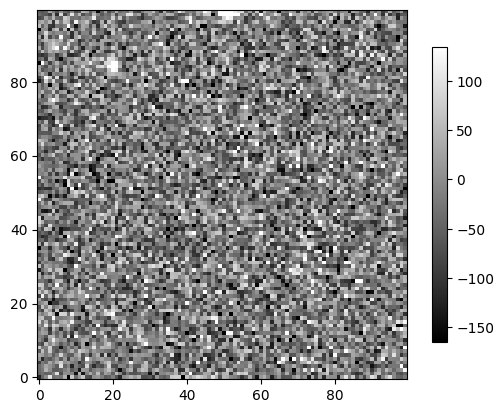

In [2]:
fn='NGC_3293_V_median_wcs.fits'
science_im=CCDData.read(fn, unit = "adu")                           

w = science_im.wcs
print(w)

skydata=science_im.data
print(skydata[0])
skydata=science_im.data[1030:1130,60:160]
p1=np.nanpercentile(skydata, 1)
p99=np.nanpercentile(skydata, 99)
plt.imshow(skydata, cmap='gray', vmin=p1, vmax=p99)
ax = plt.gca()
ax.invert_yaxis()
plt.colorbar(shrink=0.8)



In [3]:
# Lets run stats on some of this data to get the background and noise

med=np.nanmedian(skydata)
print('Median:', med)

std=np.nanstd(skydata)
print('Standard deviation:', std)


Median: -19.629855165306957
Standard deviation: 63.77490965876932


In [4]:
segimage=detect_sources(science_im.data, 2.00*std, 9, connectivity=4, mask=None)
print('Segmentation image minimum:', np.min(segimage.data))
print('Segmentation image maximum:', np.max(segimage.data))


Segmentation image minimum: 0
Segmentation image maximum: 1301


In [5]:
source_table=SourceCatalog(science_im.data, segimage, error=None, mask=None, background=None, wcs=w)
print('Source table length:\n', len(source_table))
print('\n\n')
print('First entry centroid x and y values :') 
print(source_table[0].centroid[0], source_table[0].centroid[1])
print('\n\n')
print('First source sky icrs coordinates :') # 
print(source_table[0].sky_centroid_icrs)
print(source_table[0].sky_centroid_icrs.ra, source_table[0].sky_centroid_icrs.dec)


Source table length:
 1301



First entry centroid x and y values :
194.01314681779434 2.195742420363557



First source sky icrs coordinates :
<SkyCoord (ICRS): (ra, dec) in deg
    (159.23850837, -58.10246234)>
159d14m18.63014455s -58d06m08.86441301s


In [6]:
positions = []   

for star in source_table:
    positions.append((star.centroid[0], star.centroid[1]))
print(positions[0:10]) # delete 


[(np.float64(194.01314681779434), np.float64(2.195742420363557)), (np.float64(369.2529828457113), np.float64(0.7818336216333804)), (np.float64(680.7818038333247), np.float64(9.723645295664113)), (np.float64(57.590963366473105), np.float64(5.461946156741536)), (np.float64(222.11135319011098), np.float64(5.64536074845634)), (np.float64(6.284936204103665), np.float64(6.396270234646238)), (np.float64(1335.0937763167747), np.float64(8.473654948924983)), (np.float64(443.72342931773863), np.float64(8.720142677336451)), (np.float64(99.32073255212254), np.float64(10.129594898928223)), (np.float64(174.22004144612262), np.float64(8.563396976654742))]


In [7]:

big_apertures = CircularAperture(positions, r=15.0)
big_phot_table = aperture_photometry(science_im-np.nanmedian(science_im.data), big_apertures)
print(big_phot_table[200:210])


 id      xcenter            ycenter          aperture_sum   
--- ------------------ ------------------ ------------------
201 1005.3526739890908  226.6897309314457  325424.6067828948
202  148.5390541076955 221.71688507608764  81967.83953968005
203  579.7451240304929 224.84665380721583  315077.5313862959
204  719.4818028573353 224.47461660242791 28608.574326653346
205    97.302107166785 225.61491599657268  48737.75272756214
206 1396.0555973474752  223.6392597183031 7369.9728690816055
207 360.08682427210414  228.6428392361975 151931.14618616577
208 1438.9680699072553 228.89298024982648 11267.104393836089
209  1127.627233231467 229.50033858997386  6509.748524114681
210 496.94440080957366 230.19231001559527 14336.323236272576


In [8]:
small_apertures = CircularAperture(positions, r=6.0)
small_phot_table = aperture_photometry(science_im-np.nanmedian(science_im.data), small_apertures)
print(small_phot_table[200:210])


 id      xcenter            ycenter          aperture_sum   
--- ------------------ ------------------ ------------------
201 1005.3526739890908  226.6897309314457  298371.8532753064
202  148.5390541076955 221.71688507608764 3877.8372556794293
203  579.7451240304929 224.84665380721583 27618.391270973167
204  719.4818028573353 224.47461660242791  33936.25519186628
205    97.302107166785 225.61491599657268   63260.9505871281
206 1396.0555973474752  223.6392597183031  9292.482223674344
207 360.08682427210414  228.6428392361975  149988.7286399635
208 1438.9680699072553 228.89298024982648 11664.759108824306
209  1127.627233231467 229.50033858997386  9198.999625468417
210 496.94440080957366 230.19231001559527  7632.974708853394


# Lets compare big and small aperture photometry 


Text(0, 0.5, 'Small aperture flux divided by large aperture flux')

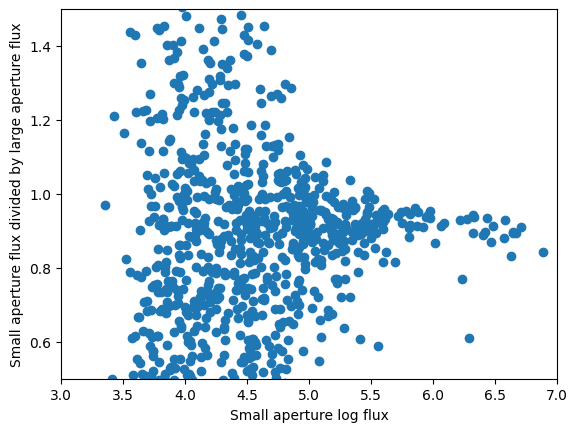

In [9]:
# Lets compare big and small aperture photometry 

px=[]
py=[]

for idx, phot in enumerate(small_phot_table):
    if phot['aperture_sum']>0.0 and phot['aperture_sum']<1.0e+7 :
        px.append(np.log10(phot['aperture_sum']))
        py.append(small_phot_table[idx]['aperture_sum']/big_phot_table[idx]['aperture_sum'])

plt.scatter(px,py)
ax = plt.gca()
ax.set_xlim([3, 7])
ax.set_ylim([0.5, 1.5])        
plt.xlabel('Small aperture log flux')
plt.ylabel('Small aperture flux divided by large aperture flux')


# Isophotal photometry

In [10]:
print('Image axes\n') 
ximax=len(science_im.data[0])
yimax=len(science_im.data)

print('Source table length:\n', len(source_table))
isoflux=[0.0]*len(source_table)
print(isoflux[0:10])
imdata=science_im-np.nanmedian(science_im.data)

# Step through the segmentation image identifying the pixels associated with objects 
yi=0
while yi<yimax: 
    xi=0
    while xi<ximax:
        idx=segimage.data[yi,xi]-1
        if idx>=0:
            # print(xi,yi)
            # print(imdata[yi,xi])
            isoflux[idx]=isoflux[idx]+imdata[yi,xi]
        xi=xi+1
    yi=yi+1

print(isoflux[200:210])


Image axes

Source table length:
 1301
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
[np.float64(310600.160930402), np.float64(3601.461484839096), np.float64(24220.10674604187), np.float64(31611.699561647125), np.float64(61426.311287386045), np.float64(5670.232077568716), np.float64(148624.4700060852), np.float64(8867.423250558015), np.float64(7057.534543173785), np.float64(6067.769785454562)]


# Lets compare isophotal and small aperture photometry 


Text(0, 0.5, 'Iso flux divided by small aperture flux')

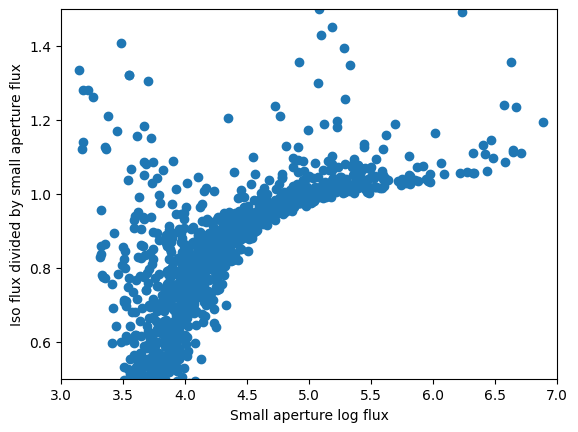

In [11]:
# Lets compare big and small aperture photometry 

px=[]
py=[]

for idx, phot in enumerate(small_phot_table):
    if phot['aperture_sum']>0.0 and phot['aperture_sum']<1.0e+7 :
        px.append(np.log10(phot['aperture_sum']))
        py.append(isoflux[idx]/phot['aperture_sum'])

plt.scatter(px,py)
ax = plt.gca()
ax.set_xlim([3, 7])
ax.set_ylim([0.5, 1.5])        
plt.xlabel('Small aperture log flux')
plt.ylabel('Iso flux divided by small aperture flux')


# Example of large elliptical aperture photometry 


In [12]:
# Example of large elliptical aperture photometry 

ellpositions = []   

ellpositions.append((845, 615)) # Position - can have more positons 
a=600                  # Major axis
b=400                  # Minor axis
theta=120*np.pi/180.0  # Measured couterclockwise from x-axis
ell_apertures = EllipticalAperture(ellpositions, a, b, theta=theta)

ell_phot_table = aperture_photometry(science_im-np.nanmedian(science_im.data), ell_apertures)

print(ell_phot_table)


 id xcenter ycenter    aperture_sum   
--- ------- ------- ------------------
  1   845.0   615.0 205178899.49699575


In [13]:
# In a previous video we found the zeropoint of this image to be 25.916296772693492

zp=25.916296772693492

mag = zp - 2.5*np.log10(ell_phot_table[0]['aperture_sum'])
print('V-mag for much of the cluster:', mag)

# How does this compare with the literature 

V-mag for much of the cluster: 5.135965032461563
